In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/paimana_clean.csv",
    encoding="utf-8-sig"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1981, 17)


,sl_no,ministry_department,sector,project_name,agency,project_code,legacy_ocms_code,pmgid,state,approval_date,start_date,target_doc,revised_doc,original_cost_cr,revised_cost_cr,cumulative_expenditure_cr,physical_progress_pct
0,1,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],612786,N04000106,-,Andhra Pradesh,03/2023,01/2024,01/2026,07/2026,265.91,265.91,129.07,65.00
1,2,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Integrated Terminal Buildi...,Airport Authority of India [AAI],701107,N04000091,4353,Andhra Pradesh,06/2020,09/2020,09/2022,10/2026,611.80,611.80,523.14,87.20
2,3,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],701121,N04000103,-,Andhra Pradesh,12/2022,08/2023,08/2025,06/2026,347.15,347.15,170.79,90.00
3,4,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Guwahati Airport New Integrated Terminal Build...,Adani Airport Holdings Limited,706724,N04000083,9925,Assam,12/2016,03/2018,03/2025,06/2026,1712.00,2520.00,2627.39,98.00
4,5,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Development of New Civil Enclave at Bihta,Airport Authority of India [AAI],612183,-,9918,Bihar,08/2024,04/2025,03/2027,-,1413.00,1413.00,7.64,1.28


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1981 entries, 0 to 1980
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sl_no                      1981 non-null   int64  
 1   ministry_department        1981 non-null   str    
 2   sector                     1981 non-null   str    
 3   project_name               1981 non-null   str    
 4   agency                     1981 non-null   str    
 5   project_code               1981 non-null   str    
 6   legacy_ocms_code           1981 non-null   str    
 7   pmgid                      1973 non-null   str    
 8   state                      1981 non-null   str    
 9   approval_date              1970 non-null   str    
 10  start_date                 1981 non-null   str    
 11  target_doc                 1981 non-null   str    
 12  revised_doc                1981 non-null   str    
 13  original_cost_cr           1981 non-null   float64
 14  rev

In [3]:
df.describe(include="all")

,sl_no,ministry_department,sector,project_name,agency,project_code,legacy_ocms_code,pmgid,state,approval_date,start_date,target_doc,revised_doc,original_cost_cr,revised_cost_cr,cumulative_expenditure_cr,physical_progress_pct
count,1981.000000,1981,1981,1981,1981,1981,1981,1973,1981,1970,1981,1981,1981,1981.000000,1981.000000,1981.000000,1981.000000
unique,NaN,17,22,1981,195,1976,1128,1208,107,213,215,190,97,NaN,NaN,NaN,NaN
top,NaN,Ministry of Road Transport & Highways,Roads & Highways,Construction of New Domestic Terminal Building...,National Highways Authority of India [NHAI],National Highways Authority of India [NHAI],-,-,Maharashtra,03/2023,03/2024,03/2026,-,NaN,NaN,NaN,NaN
freq,NaN,1137,1137,1,562,6,795,766,185,102,48,67,354,NaN,NaN,NaN,NaN
mean,991.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1874.135290,2159.718511,1027.818016,60.209621
std,572.009761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4960.200777,7236.919493,4701.135060,34.764130
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,0.100000,0.000000,0.000000
25%,496.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,355.790000,358.190000,35.570000,28.600000
50%,991.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,790.780000,786.910000,226.460000,70.000000
75%,1486.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1511.570000,1656.730000,663.380000,93.100000


In [4]:
df.isnull().sum()

sl_no                         0
ministry_department           0
sector                        0
project_name                  0
agency                        0
project_code                  0
legacy_ocms_code              0
pmgid                         8
state                         0
approval_date                11
start_date                    0
target_doc                    0
revised_doc                   0
original_cost_cr              0
revised_cost_cr               0
cumulative_expenditure_cr     0
physical_progress_pct         0
dtype: int64

In [5]:
df["sector"].value_counts()

sector
Roads & Highways                      1137
Railways                               262
Coal                                   119
Oil & Gas                               96
Transmission & Distribution             69
Electricity Generation                  40
Water Resources                         40
Healthcare                              34
Education                               31
Urban Public Transport                  27
Waste & Water                           27
Aviation & Aviation Infrastructure      26
Steel                                   18
Energy Storage                          16
Telecommunication                       12
Real Estate                             11
Metals & Mining                          6
Shipping                                 5
Construction                             2
Inland Waterways                         1
Tourism, Hospitality & Wellness          1
Logistics Infrastructure                 1
Name: count, dtype: int64

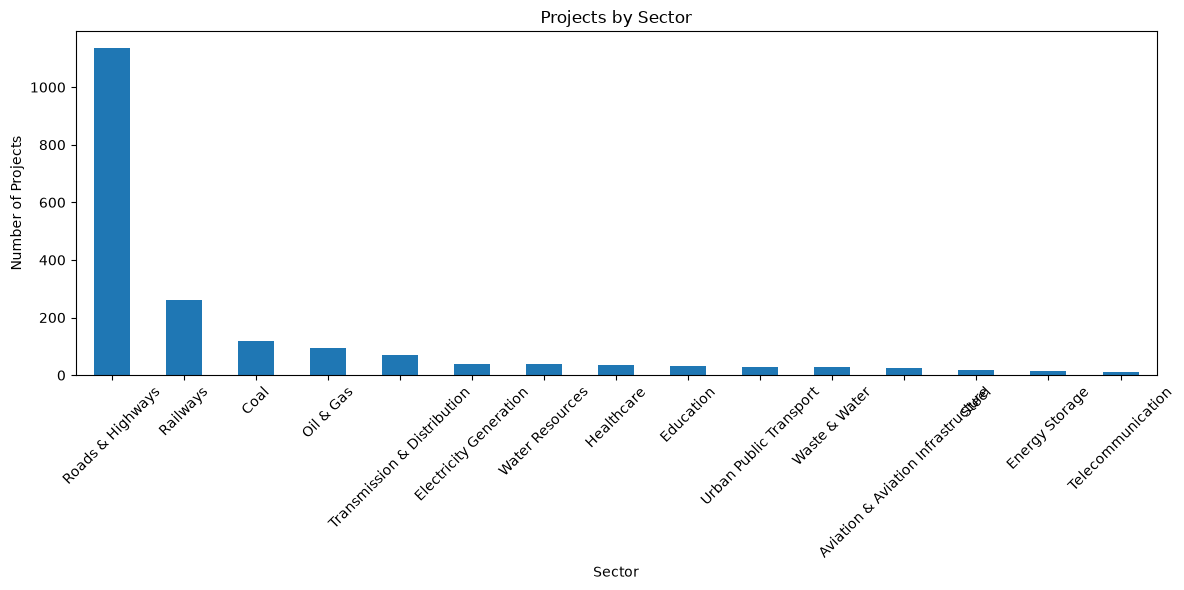

In [6]:
df["sector"].value_counts().head(15).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Projects by Sector")
plt.xlabel("Sector")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df["cost_overrun_pct"] = (
    (df["revised_cost"] - df["original_cost"])
    / df["original_cost"]
) * 100

KeyError: 'revised_cost'

In [8]:
print("Actual columns in the dataset:")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(i, ":", repr(column))

Actual columns in the dataset:
1 : 'sl_no'
2 : 'ministry_department'
3 : 'sector'
4 : 'project_name'
5 : 'agency'
6 : 'project_code'
7 : 'legacy_ocms_code'
8 : 'pmgid'
9 : 'state'
10 : 'approval_date'
11 : 'start_date'
12 : 'target_doc'
13 : 'revised_doc'
14 : 'original_cost_cr'
15 : 'revised_cost_cr'
16 : 'cumulative_expenditure_cr'
17 : 'physical_progress_pct'


In [9]:
df.head()

,sl_no,ministry_department,sector,project_name,agency,project_code,legacy_ocms_code,pmgid,state,approval_date,start_date,target_doc,revised_doc,original_cost_cr,revised_cost_cr,cumulative_expenditure_cr,physical_progress_pct
0,1,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],612786,N04000106,-,Andhra Pradesh,03/2023,01/2024,01/2026,07/2026,265.91,265.91,129.07,65.00
1,2,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Integrated Terminal Buildi...,Airport Authority of India [AAI],701107,N04000091,4353,Andhra Pradesh,06/2020,09/2020,09/2022,10/2026,611.80,611.80,523.14,87.20
2,3,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],701121,N04000103,-,Andhra Pradesh,12/2022,08/2023,08/2025,06/2026,347.15,347.15,170.79,90.00
3,4,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Guwahati Airport New Integrated Terminal Build...,Adani Airport Holdings Limited,706724,N04000083,9925,Assam,12/2016,03/2018,03/2025,06/2026,1712.00,2520.00,2627.39,98.00
4,5,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Development of New Civil Enclave at Bihta,Airport Authority of India [AAI],612183,-,9918,Bihar,08/2024,04/2025,03/2027,-,1413.00,1413.00,7.64,1.28


In [10]:
print(df.columns.tolist())

['sl_no', 'ministry_department', 'sector', 'project_name', 'agency', 'project_code', 'legacy_ocms_code', 'pmgid', 'state', 'approval_date', 'start_date', 'target_doc', 'revised_doc', 'original_cost_cr', 'revised_cost_cr', 'cumulative_expenditure_cr', 'physical_progress_pct']


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/paimana_clean.csv",
    encoding="utf-8-sig"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1981
Columns: 17


In [12]:
print(df.columns.tolist())

['sl_no', 'ministry_department', 'sector', 'project_name', 'agency', 'project_code', 'legacy_ocms_code', 'pmgid', 'state', 'approval_date', 'start_date', 'target_doc', 'revised_doc', 'original_cost_cr', 'revised_cost_cr', 'cumulative_expenditure_cr', 'physical_progress_pct']


In [13]:
df.head()

,sl_no,ministry_department,sector,project_name,agency,project_code,legacy_ocms_code,pmgid,state,approval_date,start_date,target_doc,revised_doc,original_cost_cr,revised_cost_cr,cumulative_expenditure_cr,physical_progress_pct
0,1,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],612786,N04000106,-,Andhra Pradesh,03/2023,01/2024,01/2026,07/2026,265.91,265.91,129.07,65.00
1,2,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Integrated Terminal Buildi...,Airport Authority of India [AAI],701107,N04000091,4353,Andhra Pradesh,06/2020,09/2020,09/2022,10/2026,611.80,611.80,523.14,87.20
2,3,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],701121,N04000103,-,Andhra Pradesh,12/2022,08/2023,08/2025,06/2026,347.15,347.15,170.79,90.00
3,4,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Guwahati Airport New Integrated Terminal Build...,Adani Airport Holdings Limited,706724,N04000083,9925,Assam,12/2016,03/2018,03/2025,06/2026,1712.00,2520.00,2627.39,98.00
4,5,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Development of New Civil Enclave at Bihta,Airport Authority of India [AAI],612183,-,9918,Bihar,08/2024,04/2025,03/2027,-,1413.00,1413.00,7.64,1.28


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1981 entries, 0 to 1980
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sl_no                      1981 non-null   int64  
 1   ministry_department        1981 non-null   str    
 2   sector                     1981 non-null   str    
 3   project_name               1981 non-null   str    
 4   agency                     1981 non-null   str    
 5   project_code               1981 non-null   str    
 6   legacy_ocms_code           1981 non-null   str    
 7   pmgid                      1973 non-null   str    
 8   state                      1981 non-null   str    
 9   approval_date              1970 non-null   str    
 10  start_date                 1981 non-null   str    
 11  target_doc                 1981 non-null   str    
 12  revised_doc                1981 non-null   str    
 13  original_cost_cr           1981 non-null   float64
 14  rev

In [15]:
df.describe()

,sl_no,original_cost_cr,revised_cost_cr,cumulative_expenditure_cr,physical_progress_pct
count,1981.000000,1981.000000,1981.000000,1981.000000,1981.000000
mean,991.000000,1874.135290,2159.718511,1027.818016,60.209621
std,572.009761,4960.200777,7236.919493,4701.135060,34.764130
min,1.000000,102.400000,0.100000,0.000000,0.000000
25%,496.000000,355.790000,358.190000,35.570000,28.600000
50%,991.000000,790.780000,786.910000,226.460000,70.000000
75%,1486.000000,1511.570000,1656.730000,663.380000,93.100000
max,1981.000000,108000.000000,188000.000000,124623.000000,100.000000


In [16]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
sl_no                         0
ministry_department           0
sector                        0
project_name                  0
agency                        0
project_code                  0
legacy_ocms_code              0
pmgid                         8
state                         0
approval_date                11
start_date                    0
target_doc                    0
revised_doc                   0
original_cost_cr              0
revised_cost_cr               0
cumulative_expenditure_cr     0
physical_progress_pct         0
dtype: int64


In [17]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

approval_date                0.555275
pmgid                        0.403836
sl_no                        0.000000
project_name                 0.000000
ministry_department          0.000000
agency                       0.000000
project_code                 0.000000
legacy_ocms_code             0.000000
sector                       0.000000
state                        0.000000
start_date                   0.000000
target_doc                   0.000000
revised_doc                  0.000000
original_cost_cr             0.000000
revised_cost_cr              0.000000
cumulative_expenditure_cr    0.000000
physical_progress_pct        0.000000
dtype: float64

In [18]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 1981
Duplicate rows: 0


In [19]:
print(
    "Duplicate project codes:",
    df["project_code"].duplicated().sum()
)

Duplicate project codes: 5


In [20]:
numeric_columns = [
    "original_cost_cr",
    "revised_cost_cr",
    "cumulative_expenditure_cr",
    "physical_progress_pct"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df[numeric_columns].dtypes

original_cost_cr             float64
revised_cost_cr              float64
cumulative_expenditure_cr    float64
physical_progress_pct        float64
dtype: object

In [21]:
date_columns = [
    "approval_date",
    "start_date",
    "target_doc",
    "revised_doc"
]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

df[date_columns].dtypes

C:\Users\LOQ\AppData\Local\Temp\ipykernel_23156\292030415.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(
C:\Users\LOQ\AppData\Local\Temp\ipykernel_23156\292030415.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(
C:\Users\LOQ\AppData\Local\Temp\ipykernel_23156\292030415.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(
C:\Users\LOQ\AppData\Local\Temp\ipykernel_23156\292030415.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `

approval_date    datetime64[us]
start_date       datetime64[us]
target_doc       datetime64[us]
revised_doc      datetime64[us]
dtype: object

In [22]:
df[date_columns].head()

,approval_date,start_date,target_doc,revised_doc
0,2023-03-01,2024-01-01,2026-01-01,2026-07-01
1,2020-06-01,2020-09-01,2022-09-01,2026-10-01
2,2022-12-01,2023-08-01,2025-08-01,2026-06-01
3,2016-12-01,2018-03-01,2025-03-01,2026-06-01
4,2024-08-01,2025-04-01,2027-03-01,NaT


In [23]:
df["cost_overrun_pct"] = np.where(
    df["original_cost_cr"] > 0,
    (
        (df["revised_cost_cr"] - df["original_cost_cr"])
        / df["original_cost_cr"]
    ) * 100,
    np.nan
)

df[
    [
        "project_name",
        "original_cost_cr",
        "revised_cost_cr",
        "cost_overrun_pct"
    ]
].head(10)

,project_name,original_cost_cr,revised_cost_cr,cost_overrun_pct
0,Construction of New Domestic Terminal Building...,265.91,265.91,0.000000
1,Construction of New Integrated Terminal Buildi...,611.80,611.80,0.000000
2,Construction of New Domestic Terminal Building...,347.15,347.15,0.000000
3,Guwahati Airport New Integrated Terminal Build...,1712.00,2520.00,47.196262
4,Development of New Civil Enclave at Bihta,1413.00,1413.00,0.000000
5,Development of New Civil Enclave and associate...,911.66,911.66,0.000000
6,Construction of New Domestic Terminal Building...,1216.90,1216.90,0.000000
7,Goa Airport Terminal Building Extension Project,255.69,255.69,0.000000
8,Development of Keshod Airport.,363.10,363.10,0.000000
9,Development of Dholera International Greenfiel...,1305.00,1551.00,18.850575


In [24]:
df["expenditure_ratio_pct"] = np.where(
    df["original_cost_cr"] > 0,
    (
        df["cumulative_expenditure_cr"]
        / df["original_cost_cr"]
    ) * 100,
    np.nan
)

df[
    [
        "project_name",
        "original_cost_cr",
        "cumulative_expenditure_cr",
        "expenditure_ratio_pct"
    ]
].head(10)

,project_name,original_cost_cr,cumulative_expenditure_cr,expenditure_ratio_pct
0,Construction of New Domestic Terminal Building...,265.91,129.07,48.538979
1,Construction of New Integrated Terminal Buildi...,611.80,523.14,85.508336
2,Construction of New Domestic Terminal Building...,347.15,170.79,49.197753
3,Guwahati Airport New Integrated Terminal Build...,1712.00,2627.39,153.469042
4,Development of New Civil Enclave at Bihta,1413.00,7.64,0.540694
5,Development of New Civil Enclave and associate...,911.66,374.49,41.077814
6,Construction of New Domestic Terminal Building...,1216.90,1200.67,98.666283
7,Goa Airport Terminal Building Extension Project,255.69,156.70,61.285150
8,Development of Keshod Airport.,363.10,87.88,24.202699
9,Development of Dholera International Greenfiel...,1305.00,896.82,68.721839


In [25]:
df["expenditure_progress_gap"] = (
    df["expenditure_ratio_pct"]
    - df["physical_progress_pct"]
)

df[
    [
        "project_name",
        "expenditure_ratio_pct",
        "physical_progress_pct",
        "expenditure_progress_gap"
    ]
].head(10)

,project_name,expenditure_ratio_pct,physical_progress_pct,expenditure_progress_gap
0,Construction of New Domestic Terminal Building...,48.538979,65.00,-16.461021
1,Construction of New Integrated Terminal Buildi...,85.508336,87.20,-1.691664
2,Construction of New Domestic Terminal Building...,49.197753,90.00,-40.802247
3,Guwahati Airport New Integrated Terminal Build...,153.469042,98.00,55.469042
4,Development of New Civil Enclave at Bihta,0.540694,1.28,-0.739306
5,Development of New Civil Enclave and associate...,41.077814,65.00,-23.922186
6,Construction of New Domestic Terminal Building...,98.666283,98.22,0.446283
7,Goa Airport Terminal Building Extension Project,61.285150,100.00,-38.714850
8,Development of Keshod Airport.,24.202699,33.13,-8.927301
9,Development of Dholera International Greenfiel...,68.721839,82.00,-13.278161


In [26]:
df["planned_duration_days"] = (
    df["target_doc"] - df["start_date"]
).dt.days

df[
    [
        "project_name",
        "start_date",
        "target_doc",
        "planned_duration_days"
    ]
].head(10)

,project_name,start_date,target_doc,planned_duration_days
0,Construction of New Domestic Terminal Building...,2024-01-01,2026-01-01,731
1,Construction of New Integrated Terminal Buildi...,2020-09-01,2022-09-01,730
2,Construction of New Domestic Terminal Building...,2023-08-01,2025-08-01,731
3,Guwahati Airport New Integrated Terminal Build...,2018-03-01,2025-03-01,2557
4,Development of New Civil Enclave at Bihta,2025-04-01,2027-03-01,699
5,Development of New Civil Enclave and associate...,2024-07-01,2026-07-01,730
6,Construction of New Domestic Terminal Building...,2018-10-01,2026-05-01,2769
7,Goa Airport Terminal Building Extension Project,2019-12-01,2021-12-01,731
8,Development of Keshod Airport.,2025-07-01,2027-01-01,549
9,Development of Dholera International Greenfiel...,2022-07-01,2026-06-01,1431


In [27]:
df["revised_duration_days"] = (
    df["revised_doc"] - df["start_date"]
).dt.days

df[
    [
        "project_name",
        "planned_duration_days",
        "revised_duration_days"
    ]
].head(10)

,project_name,planned_duration_days,revised_duration_days
0,Construction of New Domestic Terminal Building...,731,912.0
1,Construction of New Integrated Terminal Buildi...,730,2221.0
2,Construction of New Domestic Terminal Building...,731,1035.0
3,Guwahati Airport New Integrated Terminal Build...,2557,3014.0
4,Development of New Civil Enclave at Bihta,699,NaN
5,Development of New Civil Enclave and associate...,730,853.0
6,Construction of New Domestic Terminal Building...,2769,2769.0
7,Goa Airport Terminal Building Extension Project,731,2313.0
8,Development of Keshod Airport.,549,NaN
9,Development of Dholera International Greenfiel...,1431,1431.0


In [28]:
df["schedule_delay_days"] = (
    df["revised_doc"] - df["target_doc"]
).dt.days

df[
    [
        "project_name",
        "target_doc",
        "revised_doc",
        "schedule_delay_days"
    ]
].head(10)

,project_name,target_doc,revised_doc,schedule_delay_days
0,Construction of New Domestic Terminal Building...,2026-01-01,2026-07-01,181.0
1,Construction of New Integrated Terminal Buildi...,2022-09-01,2026-10-01,1491.0
2,Construction of New Domestic Terminal Building...,2025-08-01,2026-06-01,304.0
3,Guwahati Airport New Integrated Terminal Build...,2025-03-01,2026-06-01,457.0
4,Development of New Civil Enclave at Bihta,2027-03-01,NaT,NaN
5,Development of New Civil Enclave and associate...,2026-07-01,2026-11-01,123.0
6,Construction of New Domestic Terminal Building...,2026-05-01,2026-05-01,0.0
7,Goa Airport Terminal Building Extension Project,2021-12-01,2026-04-01,1582.0
8,Development of Keshod Airport.,2027-01-01,NaT,NaN
9,Development of Dholera International Greenfiel...,2026-06-01,2026-06-01,0.0


In [29]:
df[
    [
        "original_cost_cr",
        "revised_cost_cr",
        "cumulative_expenditure_cr",
        "physical_progress_pct",
        "cost_overrun_pct",
        "expenditure_ratio_pct",
        "expenditure_progress_gap",
        "planned_duration_days",
        "schedule_delay_days"
    ]
].describe()

,original_cost_cr,revised_cost_cr,cumulative_expenditure_cr,physical_progress_pct,cost_overrun_pct,expenditure_ratio_pct,expenditure_progress_gap,planned_duration_days,schedule_delay_days
count,1981.000000,1981.000000,1981.000000,1981.000000,1981.000000,1981.000000,1981.000000,1981.000000,1627.000000
mean,1874.135290,2159.718511,1027.818016,60.209621,8.669047,45.096748,-15.112874,1316.562847,705.791026
std,4960.200777,7236.919493,4701.135060,34.764130,50.448229,56.911622,53.186280,1301.923496,959.463499
min,102.400000,0.100000,0.000000,0.000000,-99.958099,0.000000,-100.000000,-425.000000,-10837.000000
25%,355.790000,358.190000,35.570000,28.600000,0.000000,5.747418,-38.043358,730.000000,90.000000
50%,790.780000,786.910000,226.460000,70.000000,0.000000,35.938209,-13.854120,731.000000,427.000000
75%,1511.570000,1656.730000,663.380000,93.100000,1.329356,65.858467,0.000000,1430.000000,943.000000
max,108000.000000,188000.000000,124623.000000,100.000000,1231.528018,911.649527,856.649527,14824.000000,9131.000000


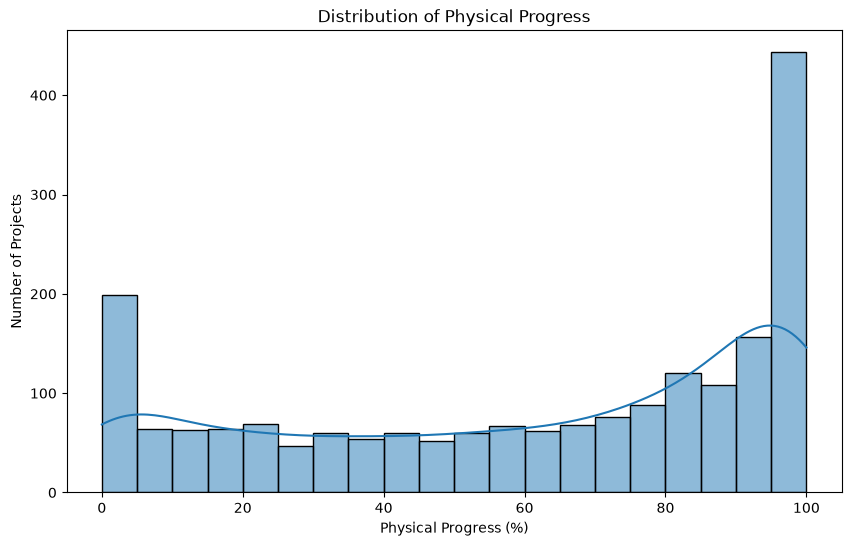

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["physical_progress_pct"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Physical Progress")
plt.xlabel("Physical Progress (%)")
plt.ylabel("Number of Projects")
plt.show()

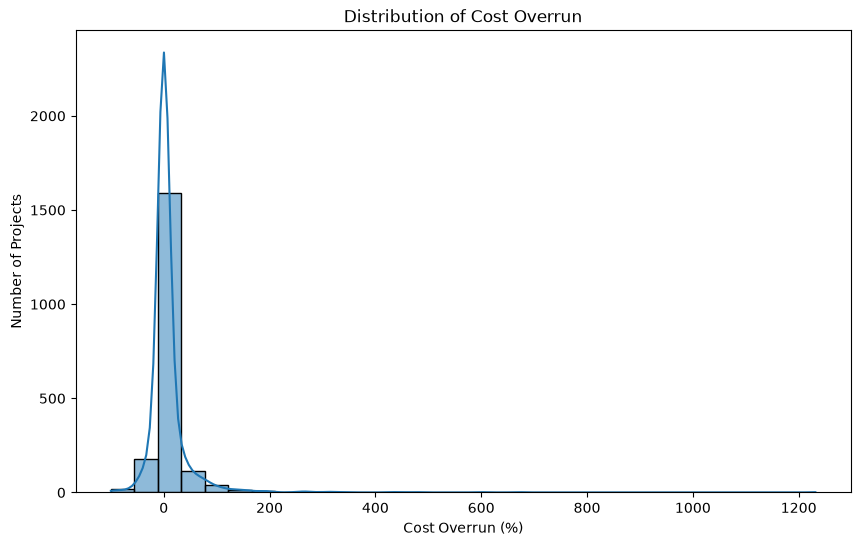

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["cost_overrun_pct"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Cost Overrun")
plt.xlabel("Cost Overrun (%)")
plt.ylabel("Number of Projects")
plt.show()

In [32]:
sector_counts = df["sector"].value_counts()

print(sector_counts)

sector
Roads & Highways                      1137
Railways                               262
Coal                                   119
Oil & Gas                               96
Transmission & Distribution             69
Electricity Generation                  40
Water Resources                         40
Healthcare                              34
Education                               31
Urban Public Transport                  27
Waste & Water                           27
Aviation & Aviation Infrastructure      26
Steel                                   18
Energy Storage                          16
Telecommunication                       12
Real Estate                             11
Metals & Mining                          6
Shipping                                 5
Construction                             2
Inland Waterways                         1
Tourism, Hospitality & Wellness          1
Logistics Infrastructure                 1
Name: count, dtype: int64


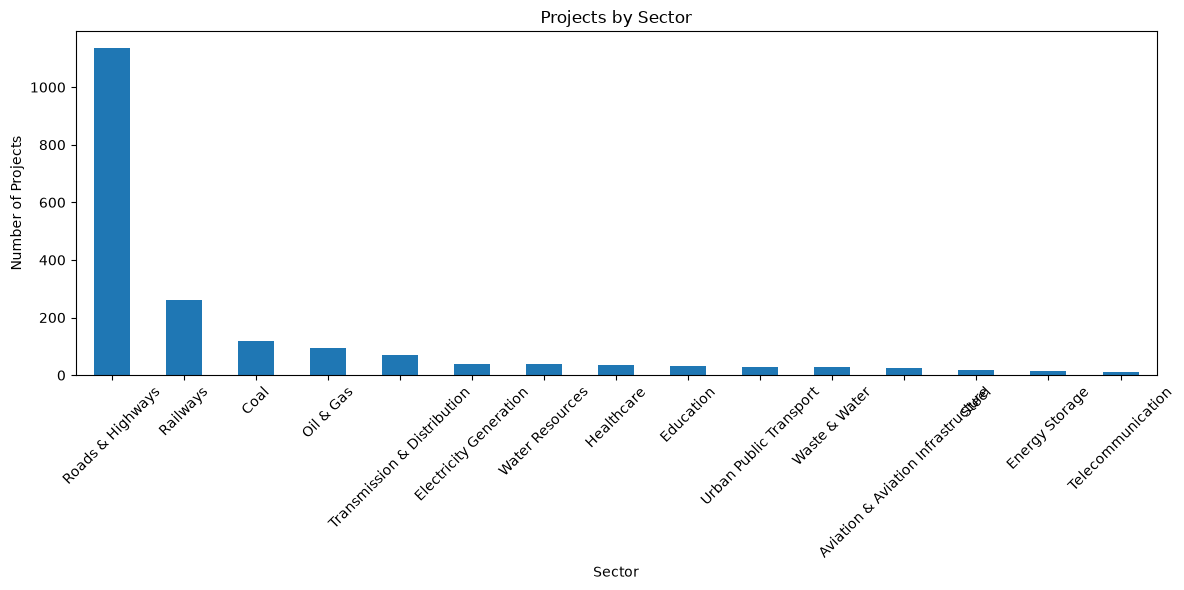

In [33]:
plt.figure(figsize=(12, 6))

sector_counts.head(15).plot(kind="bar")

plt.title("Projects by Sector")
plt.xlabel("Sector")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
state_counts = df["state"].value_counts()

print(state_counts.head(20))

state
Maharashtra          185
Uttar Pradesh        141
Andhra Pradesh       109
Gujarat              108
Bihar                102
Karnataka             99
Madhya Pradesh        98
Odisha                93
Assam                 79
Jharkhand             77
Telangana             70
Chhattisgarh          67
West Bengal           59
Rajasthan             55
Tamil Nadu            53
Jammu and Kashmir     45
Uttarakhand           43
Punjab                42
Manipur               34
Kerala                29
Name: count, dtype: int64


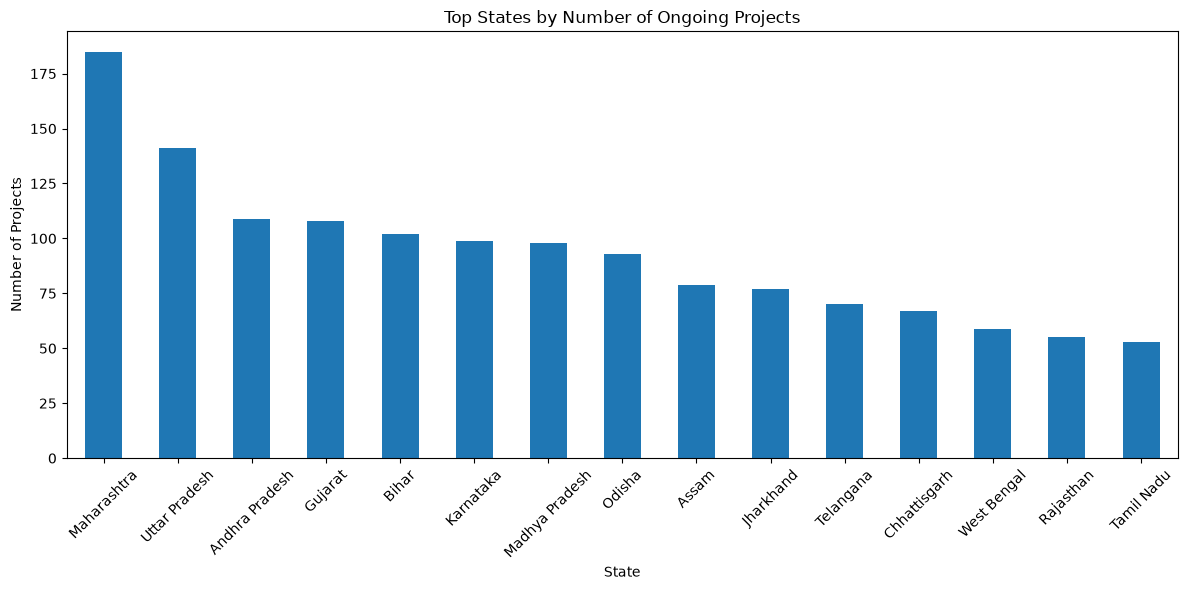

In [35]:
plt.figure(figsize=(12, 6))

state_counts.head(15).plot(kind="bar")

plt.title("Top States by Number of Ongoing Projects")
plt.xlabel("State")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
ministry_counts = df["ministry_department"].value_counts()

print(ministry_counts.head(20))

ministry_department
Ministry of Road Transport & Highways                    1137
Ministry of Railways                                      260
Ministry of Coal                                          128
Ministry of Petroleum & Natural Gas                       112
Ministry of Power                                         102
Ministry of Housing & Urban Affairs                        51
Department of Water Resources, River Development & GR      48
Department of Higher Education                             30
Ministry of Civil Aviation                                 26
Ministry of Health & Family Welfare                        23
Ministry of Steel                                          19
Department of Telecommunications                           12
Ministry of Labour and Employment                          11
Department for Promotion of Industry & Internal Trade       8
Ministry of Ports, Shipping and Waterways                   7
Ministry of Mines                                 

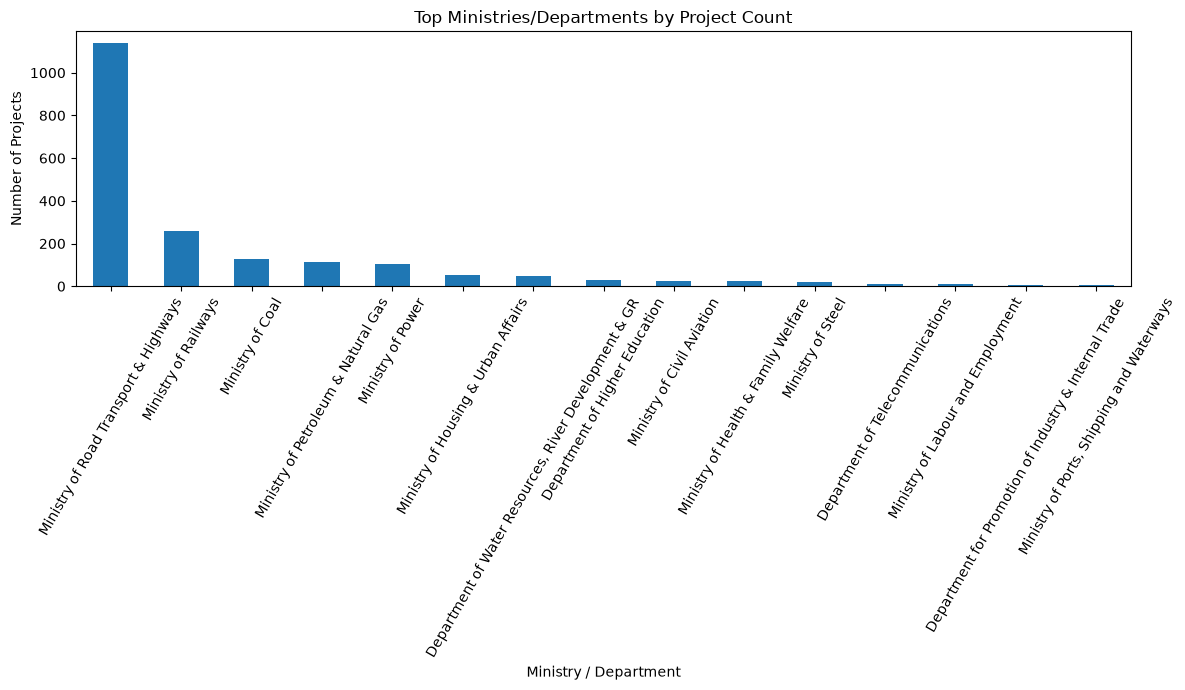

In [37]:
plt.figure(figsize=(12, 7))

ministry_counts.head(15).plot(kind="bar")

plt.title("Top Ministries/Departments by Project Count")
plt.xlabel("Ministry / Department")
plt.ylabel("Number of Projects")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [38]:
OUTPUT_FILE = "../data/processed/paimana_phase1_features.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Phase 1 dataset saved successfully!")
print(OUTPUT_FILE)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Phase 1 dataset saved successfully!
../data/processed/paimana_phase1_features.csv
Rows: 1981
Columns: 23


In [2]:
df = pd.read_csv(
    "../data/processed/paimana_features.csv",
    encoding="utf-8-sig"
)

print(df.shape)

NameError: name 'pd' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    "../data/processed/paimana_features.csv",
    encoding="utf-8-sig"
)

print("Dataset loaded!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded!
Rows: 1981
Columns: 30


In [5]:
df = pd.read_csv(
    "../data/processed/paimana_features.csv",
    encoding="utf-8-sig"
)

print(df.shape)

(1981, 30)


In [6]:
df.head()

,sl_no,ministry_department,sector,project_name,agency,project_code,legacy_ocms_code,pmgid,state,approval_date,...,expenditure_progress_gap,planned_duration_days,revised_duration_days,schedule_delay_days,schedule_delay_months,schedule_delay_pct,project_size_category,has_revised_cost,has_revised_completion,has_physical_progress
0,1,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],612786,N04000106,-,Andhra Pradesh,2023-03-01,...,-16.461021,731,912.0,181.0,5.946124,24.760602,Small,1,1,1
1,2,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Integrated Terminal Buildi...,Airport Authority of India [AAI],701107,N04000091,4353,Andhra Pradesh,2020-06-01,...,-1.691664,730,2221.0,1491.0,48.981603,204.246575,Medium,1,1,1
2,3,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],701121,N04000103,-,Andhra Pradesh,2022-12-01,...,-40.802247,731,1035.0,304.0,9.986859,41.586867,Small,1,1,1
3,4,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Guwahati Airport New Integrated Terminal Build...,Adani Airport Holdings Limited,706724,N04000083,9925,Assam,2016-12-01,...,55.469042,2557,3014.0,457.0,15.013141,17.872507,Large,1,1,1
4,5,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Development of New Civil Enclave at Bihta,Airport Authority of India [AAI],612183,-,9918,Bihar,2024-08-01,...,-0.739306,699,NaN,NaN,NaN,NaN,Large,1,0,1


In [7]:
df[
    [
        "original_cost_cr",
        "revised_cost_cr",
        "cost_increase_cr",
        "cost_overrun_pct",
        "cumulative_expenditure_cr",
        "expenditure_ratio_pct"
    ]
].describe()

,original_cost_cr,revised_cost_cr,cost_increase_cr,cost_overrun_pct,cumulative_expenditure_cr,expenditure_ratio_pct
count,1981.000000,1981.000000,1981.000000,1981.000000,1981.000000,1981.000000
mean,1874.135290,2159.718511,285.583221,8.669047,1027.818016,45.096748
std,4960.200777,7236.919493,3649.404263,50.448229,4701.135060,56.911622
min,102.400000,0.100000,-8874.000000,-99.958099,0.000000,0.000000
25%,355.790000,358.190000,0.000000,0.000000,35.570000,5.747418
50%,790.780000,786.910000,0.000000,0.000000,226.460000,35.938209
75%,1511.570000,1656.730000,12.820000,1.329356,663.380000,65.858467
max,108000.000000,188000.000000,126891.000000,1231.528018,124623.000000,911.649527


In [8]:
df[
    [
        "project_name",
        "original_cost_cr",
        "revised_cost_cr",
        "cost_overrun_pct"
    ]
].sort_values(
    "cost_overrun_pct",
    ascending=False
).head(20)

,project_name,original_cost_cr,revised_cost_cr,cost_overrun_pct
631,Baramati Lonand New Line Project,138.48,1843.90,1231.528018
681,"New line Dahod-Indore via Sardarpur, Jabuwa an...",456.07,3516.77,671.103120
1962,Aruna Medium Irrigation Project,210.45,1472.14,599.520076
1963,Lower Pedhi Project,255.97,1480.70,478.466227
1943,Polavaram Irrigation Project,10151.04,55548.90,447.223733
1968,Integrated Anandpur Barrage Project,567.03,2990.05,427.317779
1974,Indiramma Flood Flow Canal Project,1331.30,5940.09,346.187185
1979,Madhya Ganga canal Phase-II,1060.67,4417.21,316.454694
176,Subansiri Lower HE Project [2000 MW],6285.33,26075.50,314.862863
696,Ratlam-Mhow-Khandwa-Akola Gauge Conversion,1656.25,6499.86,292.444377


In [9]:
df[
    [
        "project_name",
        "physical_progress_pct",
        "expenditure_ratio_pct",
        "expenditure_progress_gap"
    ]
].sort_values(
    "expenditure_progress_gap",
    ascending=False
).head(20)

,project_name,physical_progress_pct,expenditure_ratio_pct,expenditure_progress_gap
681,"New line Dahod-Indore via Sardarpur, Jabuwa an...",55.00,911.649527,856.649527
1962,Aruna Medium Irrigation Project,98.10,824.286054,726.186054
631,Baramati Lonand New Line Project,60.00,727.534662,667.534662
1963,Lower Pedhi Project,65.00,592.299879,527.299879
1968,Integrated Anandpur Barrage Project,62.85,489.609015,426.759015
1979,Madhya Ganga canal Phase-II,82.39,431.400907,349.010907
176,Subansiri Lower HE Project [2000 MW],97.64,416.053254,318.413254
1974,Indiramma Flood Flow Canal Project,92.00,337.345452,245.345452
489,CONSTRUCTION OF 300 BEDDED HOSPITAL AT HARIDWAR,84.00,327.011719,243.011719
1964,Nardave Medium Irrigation Project,72.59,296.065450,223.475450


In [10]:
df[
    [
        "project_name",
        "physical_progress_pct",
        "expenditure_ratio_pct",
        "expenditure_progress_gap"
    ]
].sort_values(
    "expenditure_progress_gap",
    ascending=False
).head(20)

,project_name,physical_progress_pct,expenditure_ratio_pct,expenditure_progress_gap
681,"New line Dahod-Indore via Sardarpur, Jabuwa an...",55.00,911.649527,856.649527
1962,Aruna Medium Irrigation Project,98.10,824.286054,726.186054
631,Baramati Lonand New Line Project,60.00,727.534662,667.534662
1963,Lower Pedhi Project,65.00,592.299879,527.299879
1968,Integrated Anandpur Barrage Project,62.85,489.609015,426.759015
1979,Madhya Ganga canal Phase-II,82.39,431.400907,349.010907
176,Subansiri Lower HE Project [2000 MW],97.64,416.053254,318.413254
1974,Indiramma Flood Flow Canal Project,92.00,337.345452,245.345452
489,CONSTRUCTION OF 300 BEDDED HOSPITAL AT HARIDWAR,84.00,327.011719,243.011719
1964,Nardave Medium Irrigation Project,72.59,296.065450,223.475450


In [12]:
df["cost_warning"] = np.where(
    df["cost_overrun_pct"] > 10,
    1,
    0
)

df["schedule_warning"] = np.where(
    df["schedule_delay_days"] > 180,
    1,
    0
)

df["progress_warning"] = np.where(
    df["expenditure_progress_gap"] > 20,
    1,
    0
)

In [13]:
print("Cost warning projects:",
      df["cost_warning"].sum())

print("Schedule warning projects:",
      df["schedule_warning"].sum())

print("Progress warning projects:",
      df["progress_warning"].sum())

Cost warning projects: 366
Schedule warning projects: 1149
Progress warning projects: 183
